## Import required Libraries

In [1]:
import keras
import tensorflow as tf
from matplotlib import pyplot as plt
import numpy as np

## Loading The Dataset

In [2]:
 (x_train,_),(x_test,_)= keras.datasets.mnist.load_data(path="mnist.npz")


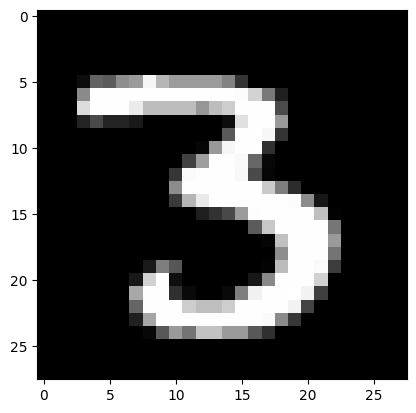

In [3]:
plt.imshow(x_train[12],cmap="grey")

In [4]:
x_train.shape # so we need to specify the dimention of the image for good practice

(60000, 28, 28)

## Data Preprocessing

In [5]:
x_train = x_train.reshape(60000, 28, 28,1)
x_test = x_test.reshape(10000, 28, 28,1) # here we specify this , to denote this is a Black & White image

### Normalizing the image's pixcel value

In [6]:
x_train = x_train/255.0
x_test = x_test/255.0

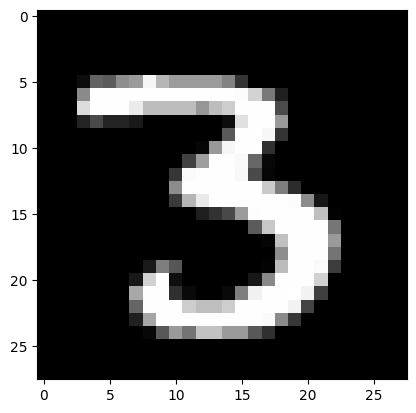

In [7]:
plt.imshow(x_train[12],cmap="grey")

In [8]:
x_train_noise = x_train + 0.25*np.random.normal(loc=0.0, scale=0.75, size=(60000, 28, 28,1))
x_test_noise  = x_test  + 0.25*np.random.normal(loc=0.0, scale=0.75, size=(10000, 28, 28,1))

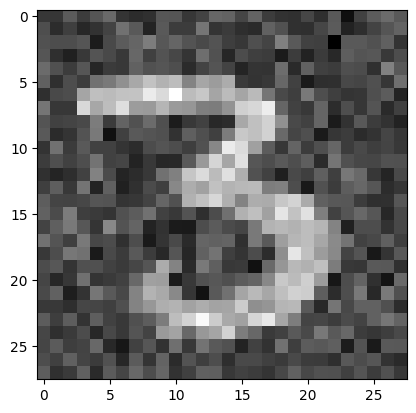

In [9]:
plt.imshow(x_train_noise[12],cmap="grey")

In [10]:
x_train_noise.max(),x_train_noise.min()

(np.float64(1.9617903167998958), np.float64(-1.1139658905154612))

## Clipping 

In [11]:
x_train_clip=np.clip(x_train_noise,0.,1)
x_test_clip=np.clip(x_test_noise,0.,1)

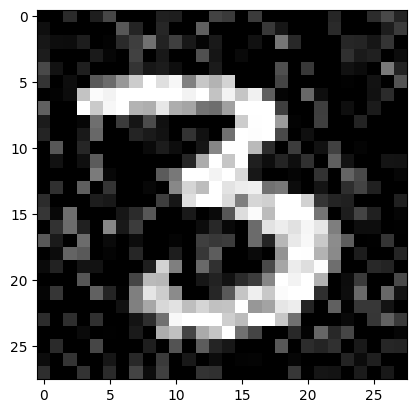

In [12]:
plt.imshow(x_train_clip[12],cmap='grey')

## Model Building

In [35]:
from keras import Sequential
from keras.layers import Conv2D,MaxPool2D,UpSampling2D
import warnings
warnings.filterwarnings("ignore")

In [36]:
Model = Sequential()

In [37]:
#Encoding
Model.add(Conv2D(filters = 32,kernel_size=(3,3),strides=(1, 1),padding='same',activation='relu',input_shape = (28, 28,1)))
Model.add(MaxPool2D(pool_size=(2, 2)))
Model.add(Conv2D(filters = 8,kernel_size=(3,3),strides=(1, 1),padding='same',activation='relu'))
Model.add(MaxPool2D(pool_size=(2, 2)))

#Decoding
Model.add(Conv2D(filters = 8,kernel_size=(3,3),strides=(1, 1),padding='same',activation='relu'))
Model.add(UpSampling2D(size=(2, 2)))
Model.add(Conv2D(filters = 32,kernel_size=(3,3),strides=(1, 1),padding='same',activation='relu'))
Model.add(UpSampling2D(size=(2, 2)))
Model.add(Conv2D(filters = 1,kernel_size=(3,3),strides=(1, 1),padding='same',activation='relu'))
Model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)                   │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 14, 14, 8)           │           2,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 7, 7, 8)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 7, 7, 8)             │             584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_2 (UpSampling2D)       │ (None, 14, 14, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_18 (Conv2D)                   │ (None, 14, 14, 32)          │           2,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_3 (UpSampling2D)       │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_19 (Conv2D)                   │ (None, 28, 28, 1)           │             289 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,841 (22.82 KB)

 Trainable params: 5,841 (22.82 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
Model.compile(optimizer='adam',loss=['mean_squared_error'],metrics=['accuracy'])

In [44]:
Model.fit(x=x_train_noise, y=x_train,batch_size=31,epochs=5,validation_data=(x_test,x_test_clip))

Epoch 1/5
1936/1936 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8152 - loss: 0.0044 - val_accuracy: 0.4599 - val_loss: 0.0211
Epoch 2/5
1936/1936 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8152 - loss: 0.0044 - val_accuracy: 0.4599 - val_loss: 0.0213
Epoch 3/5
1936/1936 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8152 - loss: 0.0044 - val_accuracy: 0.4599 - val_loss: 0.0211
Epoch 4/5
1936/1936 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8152 - loss: 0.0043 - val_accuracy: 0.4598 - val_loss: 0.0214
Epoch 5/5
1936/1936 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8153 - loss: 0.0043 - val_accuracy: 0.4599 - val_loss: 0.0213


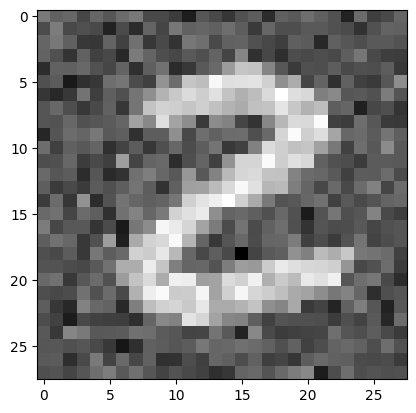

In [47]:
plt.imshow(x_train_noise[25],cmap='grey')

In [58]:
 y_pred= Model.predict(x_train_clip)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


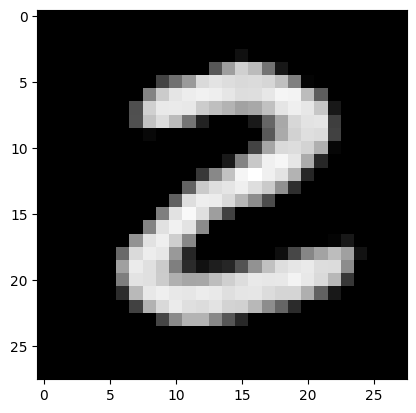

In [59]:
plt.imshow(y_pred[25],cmap='grey')

## Save Model

In [61]:
Model.save('Image_restore_bw.keras')

In [74]:
from PIL import Image
image = Image.open(r"C:\Users\Admin\Pictures\Screenshots\Screenshot 2026-08-01 191958.png")
image =image.resize((28, 28))
image = image.convert("L")
Model.predict(x=image)

ValueError: Unrecognized data type: x=<PIL.Image.Image image mode=L size=28x28 at 0x1AE46CDB5B0> (of type <class 'PIL.Image.Image'>)

In [76]:
import numpy as np
from PIL import Image

image = Image.open(r"C:\Users\Admin\Pictures\Screenshots\Screenshot 2026-08-01 191958.png")
image = image.resize((28, 28))
image = image.convert("L")

# 1. Convert the PIL image to a NumPy numerical array
image_array = np.array(image)

# 2. Normalize pixel values to a 0-1 range (Standard for 28x28 models like MNIST)
image_array = image_array / 255.0

# 3. Add the batch dimension and channel dimension: shape changes from (28, 28) to (1, 28, 28, 1)
processed_image = np.expand_dims(image_array, axis=(0, -1))

# 4. Run the prediction successfully
predictions = Model.predict(x=processed_image)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


TypeError: Invalid shape (1, 28, 28, 1) for image data

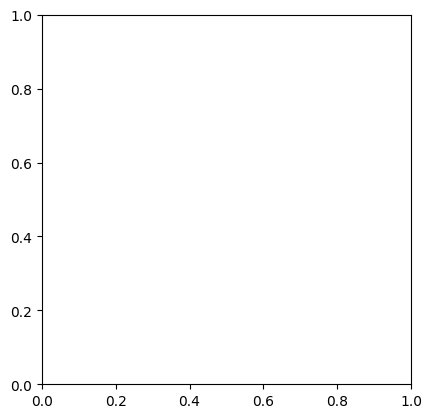

In [78]:
plt.imshow(predictions)